In [7]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out
    
    
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
L

Value(data=-8.0)

In [6]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


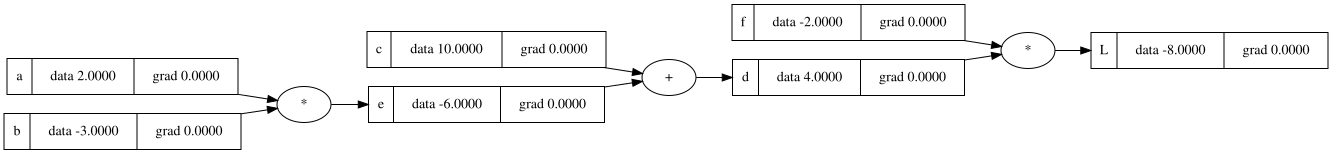

In [8]:
draw_dot(L)

In [13]:
# To deduce the gradient

def lol():
    h = 0.0001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    a = Value(2.0 + h, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L2 = L.data

    print((L2 - L1) / h)

lol()

6.000000000021544


In [16]:
# To deduce the gradient

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    # L2 = L.data
    L2 = L.data + h

    print((L2 - L1) / h)

lol()

1.000000000000334


In [17]:
L.grad = 1

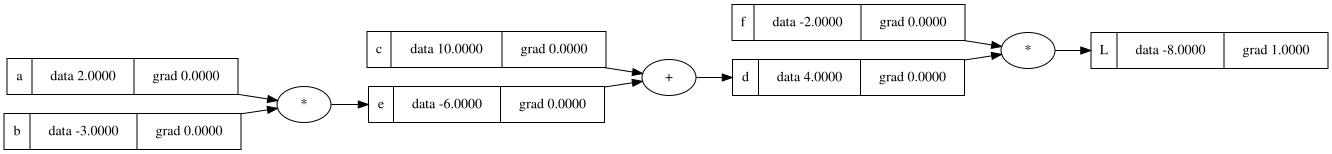

In [19]:
draw_dot(L)

In [37]:
# Theoretical mathematical proof

# L = d * f

# dL/dd =? f

# (f(x+h) - f(x)) / h
# ((d+h)*f - d*f) / h
# (d*f + h*f - d*f) /h
# (h*f) / h
# f

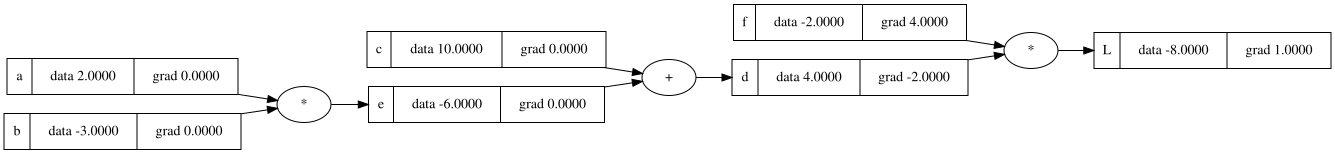

In [35]:
f.grad = d.data
# f.grad = 4

draw_dot(L)

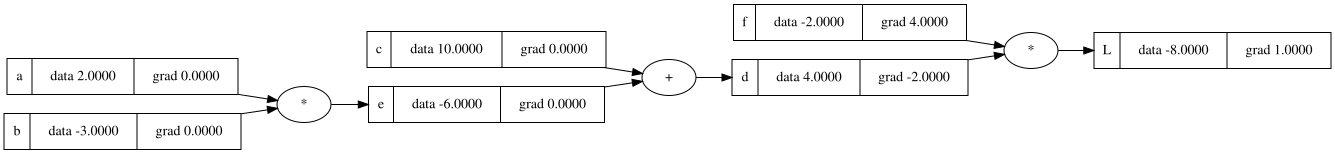

In [36]:
d.grad = f.data
# d.grad = -2

draw_dot(L)

In [43]:
# Imperial proof for f variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    # f = Value(-2.0, label="f")
    f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()

3.9999999999995595


In [42]:
# Imperial proof for d variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    d.data += h
    # f = Value(-2.0, label="f")
    # f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()

-2.000000000000668
